# Taxi Price Prediction
https://www.kaggle.com/datasets/denkuznetz/taxi-price-prediction

In [ ]:
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_transformer, make_column_selector

# Questions 
How do you determine which categorical columns to keep?

In [2]:
df = pd.read_csv('taxi_trip_pricing.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


# Performing EDA

In [6]:
df.isnull().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [25]:
#drop the null target column ( Trip_Price)
df = df.dropna(subset = ['Trip_Price'])

In [26]:
#get unique vales in each columns
df.nunique()

Trip_Distance_km         827
Time_of_Day                4
Day_of_Week                2
Passenger_Count            4
Traffic_Conditions         3
Weather                    3
Base_Fare                286
Per_Km_Rate              150
Per_Minute_Rate           41
Trip_Duration_Minutes    873
Trip_Price               951
dtype: int64

In [27]:
#list the non-numerical columns
df_cat = df.select_dtypes(include=['object'])
df_cat

,Time_of_Day,Day_of_Week,Traffic_Conditions,Weather
0,Morning,Weekday,Low,Clear
2,Evening,Weekend,High,Clear
3,Evening,Weekday,Low,NaN
4,Evening,Weekday,High,Clear
5,Afternoon,Weekend,Medium,Clear
...,...,...,...,...
995,Afternoon,Weekend,Medium,Clear
996,Night,Weekday,Medium,Clear
997,Morning,Weekday,Low,Rain
998,Morning,Weekday,Low,Clear


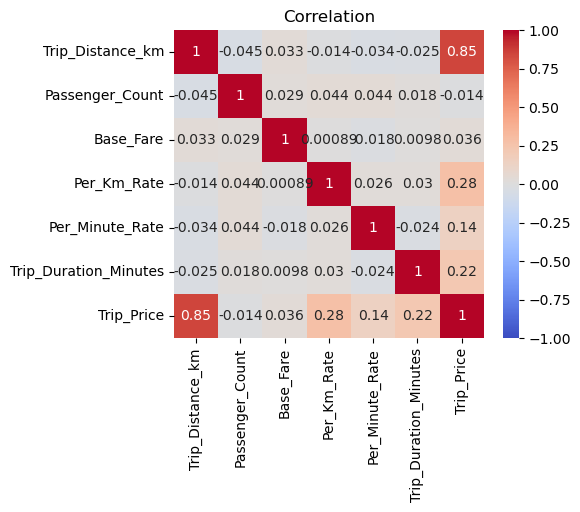

In [28]:
#get numerical fields and perform correlation matrix
df_numeric = df.select_dtypes(include=['float64'])
corr_matrix = df_numeric.corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation')
plt.show()

#Conclusion:: From matrix it is clear Trip_price is highly co-related to Trip_Distance,Trip_Diration,Per minute rate, per_km_rate

In [31]:
#Determine highly correlated columns
corr_matrix = df_numeric.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 3. Unstack the matrix to get a Series of pairs and sort in descending order
highest_corr_pairs = upper_triangle.stack().sort_values(ascending=False)

highest_corr_pairs

#Conclusion : As seen frm result we can drop Base_Fare and Passenger_count column since they do not affect Trip price

Trip_Distance_km       Trip_Price               0.849123
Per_Km_Rate            Trip_Price               0.275135
Trip_Duration_Minutes  Trip_Price               0.221211
Per_Minute_Rate        Trip_Price               0.141226
Trip_Distance_km       Passenger_Count          0.044907
Passenger_Count        Per_Minute_Rate          0.044471
                       Per_Km_Rate              0.044414
Base_Fare              Trip_Price               0.035533
Trip_Distance_km       Per_Minute_Rate          0.034204
                       Base_Fare                0.032846
Per_Km_Rate            Trip_Duration_Minutes    0.029811
Passenger_Count        Base_Fare                0.029051
Per_Km_Rate            Per_Minute_Rate          0.026362
Trip_Distance_km       Trip_Duration_Minutes    0.024653
Per_Minute_Rate        Trip_Duration_Minutes    0.023765
Base_Fare              Per_Minute_Rate          0.018287
Passenger_Count        Trip_Duration_Minutes    0.017739
Trip_Distance_km       Per_Km_R

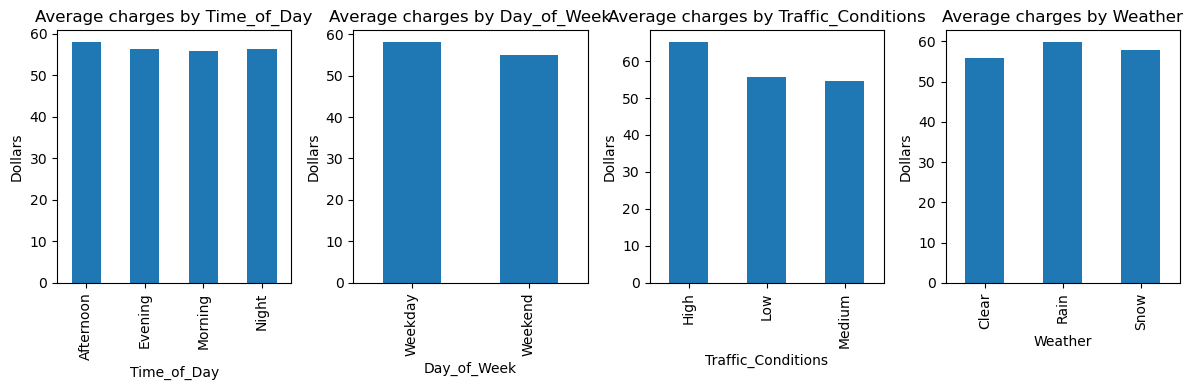

In [36]:
# Let's explore the medical cost by categorical variable
categorical_columns = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions','Weather']

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for i, column in enumerate(categorical_columns):
    mean_costs = df.groupby(column)['Trip_Price'].mean()
    mean_costs.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Average charges by {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Dollars')

plt.tight_layout()
plt.show()

#Conclusion - Average cost doesnt seem to be affected by the time of day, this column can be dropped as well.

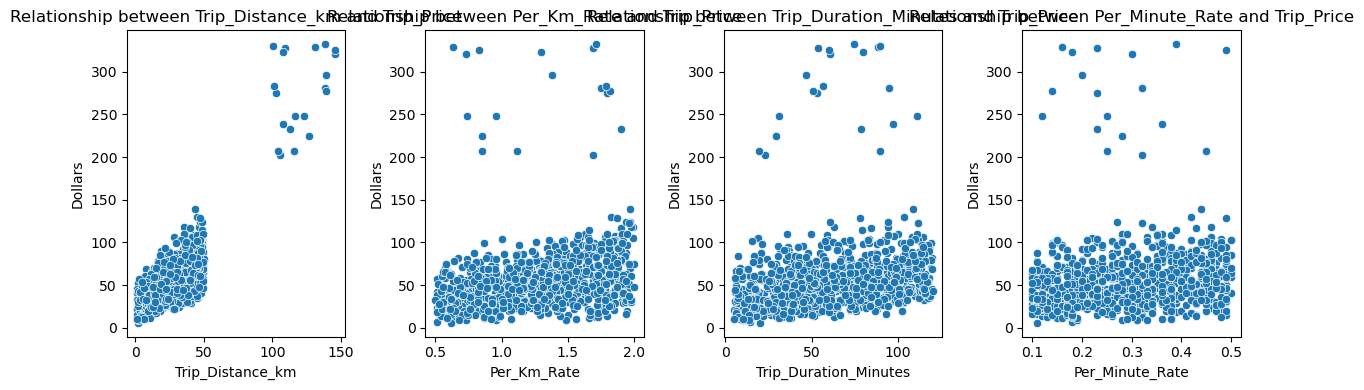

In [117]:
# Numerical variables
numerical_columns = ['Trip_Distance_km', 'Per_Km_Rate', 'Trip_Duration_Minutes','Per_Minute_Rate']

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for i, column in enumerate(numerical_columns):
    sns.scatterplot(x=df[column], y=df['Trip_Price'], ax=axes[i])
    axes[i].set_title(f'Relationship between {column} and Trip_Price')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Dollars')

plt.tight_layout()
plt.show()

# Feature engineering

In [121]:
# Divide data into train and test 
X = df.drop(columns=['Trip_Price','Time_of_Day','Passenger_Count','Base_Fare'])  # Here we get rid off the charges because it's the target variable
y = df['Trip_Price']
# Divide the dataset into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape

(760, 7)

In [122]:
#Instantiate transformer pipelines
traffic_cats = ['Low','Medium','High']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

onehot_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[traffic_cats]))
])



In [123]:
# Create a preprocessor that applies both one-hot encoding for categorical variables and scaling for numerical variables
#Apply One-hot encoding for unordered categories and Ordinal encoding for ordered data(like low,medium, high) 

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_columns),  # Standarize numerical features
        ('one_hotcat', onehot_transformer, ['Day_of_Week','Weather']),
        ('ord_cat', ordinal_transformer,['Traffic_Conditions'])
    ])

#Create pipeline
#pipe = Pipeline([('transformer',preprocessor), ('linreg', LinearRegression())])
X_transformed = preprocessor.fit_transform(X_train)

feature_names = preprocessor.get_feature_names_out()
print(feature_names)


['num__Trip_Distance_km' 'num__Per_Km_Rate' 'num__Trip_Duration_Minutes'
 'num__Per_Minute_Rate' 'one_hotcat__Day_of_Week_Weekday'
 'one_hotcat__Day_of_Week_Weekend' 'one_hotcat__Weather_Clear'
 'one_hotcat__Weather_Rain' 'one_hotcat__Weather_Snow'
 'ord_cat__Traffic_Conditions']


# Perform Linear Regression

In [124]:
pipe = Pipeline(steps=[
    ('preprocessor',preprocessor), ('linreg', LinearRegression())
])
pipe.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Trip_Distance_km',
                                                   'Per_Km_Rate',
                                                   'Trip_Duration_Minutes',
                                                   'Per_Minute_Rate']),
                                                 ('one_hotcat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Day_of_Week', 'Weather']),
                                                 ('ord_cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High']]))]),
                                                  ['Traffic_Conditions'])])),
                ('linreg', LinearRegression())])

# Evaluate model

In [136]:
#predict on train and test
pred_train = pipe.predict(X_train)
pred_test = pipe.predict(X_test)
#compute mean squared errors
mse_train = mean_squared_error(y_train,pred_train)
mse_test = mean_squared_error(y_test,pred_test)

from sklearn.metrics import r2_score

train_r2 = r2_score(y_train, pred_train)
test_r2 = r2_score(y_test, pred_test)

print(f"Training R-squared: {train_r2}")
print(f"Test R-squared: {test_r2}")
print(f'MSE Training {mse_train}')
print(f'MSE Test {mse_test}')

#R² on train vs test
#Large drop → overfitting
#Small drop → healthy model --- since its a small drop, it indicates our model is healthy

#Mean squared error -> test has 37% of train error, indicates there is not a large difference in error.

Training R-squared: 0.8564510400957722
Test R-squared: 0.877498552324642
MSE Training 209.05086210050465
MSE Test 286.3322935034337


In [126]:
#Calculate baseline MSE

baseline_train = np.ones(shape = y_train.shape) * y_train.mean()
baseline_test = np.ones(shape = y_test.shape) * y_test.mean()
mse_baseline_train = mean_squared_error(baseline_train,y_train)
mse_baseline_test = mean_squared_error(baseline_test,y_test)

# Answer check
print(baseline_train.shape, baseline_test.shape)
print(f'Baseline for training data: {mse_baseline_train}')
print(f'Baseline for testing data: {mse_baseline_test}')

(760,) (191,)
Baseline for training data: 1456.3035652782028
Baseline for testing data: 2337.3788550013314


In [137]:
#Perform CV 
from sklearn.model_selection import cross_val_score

# Set scoring to neg_mean_squared_error
scores = cross_val_score(pipe, X, y, cv=5, scoring='neg_mean_squared_error')

# Convert to positive and find average
cv_mse = (-scores).mean()

print(cv_mse)
#If CV MSE is close to ~250–300 this is a good model

234.85195023980424
